In [1]:


import os
import glob

import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import xarray as xr
import rioxarray as rio
import pandas as pd
import datetime as dt
import cartopy.crs as ccrs

import GRSl2bgen

opj = os.path.join

print(f'-GRSl2bgen: {GRSl2bgen.__version__}')

-GRSl2bgen: 0.1.0


In [2]:

l2a_path ='/data/satellite/Sentinel-2/subset/L2A/ambracian/2024/07/06/S2B_MSIL2A_20240706T091559_N0510_R093_T34SDJ_20240706T101118'


In [3]:
prod = GRSl2bgen.Product(l2a_path)
prod.raster

INFO:root:Load L2A from files


<xarray.Dataset> Size: 2GB
Dimensions:             (wl: 11, y: 3206, x: 4400)
Coordinates:
  * wl                  (wl) int64 88B 443 490 560 665 705 ... 842 865 1610 2190
    time                datetime64[ns] 8B ...
  * x                   (x) float64 35kB 4.728e+05 4.728e+05 ... 5.097e+05
  * y                   (y) float64 26kB 4.331e+06 4.331e+06 ... 4.299e+06
    central_wavelength  (wl) float32 44B dask.array<chunksize=(11,), meta=np.ndarray>
    spatial_ref         int64 8B ...
Data variables:
    Rrs                 (wl, y, x) float64 1GB dask.array<chunksize=(11, 1069, 1467), meta=np.ndarray>
    BRDFg               (y, x) float64 113MB dask.array<chunksize=(1603, 2200), meta=np.ndarray>
    aot550              (y, x) float64 113MB dask.array<chunksize=(1603, 2200), meta=np.ndarray>
    wind                (y, x) float64 113MB dask.array<chunksize=(3206, 4400), meta=np.ndarray>
    mask                (y, x) uint8 14MB dask.array<chunksize=(3206, 4400), meta=np.ndarray>
    vza                 (y, x) float64 113MB dask.array<chunksize=(1603, 2200), meta=np.ndarray>
    sza                 (y, x) float64 113MB dask.array<chunksize=(1603, 2200), meta=np.ndarray>
    raa                 (y, x) float64 113MB dask.array<chunksize=(1603, 2200), meta=np.ndarray>
    flags               (y, x) int64 113MB dask.array<chunksize=(1069, 1467), meta=np.ndarray>
    dem                 (y, x) float64 113MB dask.array<chunksize=(1603, 2200), meta=np.ndarray>
Attributes: (12/73)
    long_name:                           CA BLUE GREEN RED VRE_1 VRE_2 VRE_3 ...
    constellation:                       Sentinel-2
    constellation_id:                    S2
    product_path:                        /data/satellite/Sentinel-2/L1C/34SDJ...
    product_name:                        S2B_MSIL1C_20240706T091559_N0510_R09...
    product_filename:                    S2B_MSIL1C_20240706T091559_N0510_R09...
    ...                                  ...
    vis_swir_index_threshold:            0.0
    hcld_threshold:                      0.003
    dirdata:                             /data/grs/grsdata
    abs_gas_file:                        /home/harmel/anaconda3/envs/py12/lib...
    water_vapor_transmittance_file:      /home/harmel/anaconda3/envs/py12/lib...
    metadata_profile:                    datacube

In [4]:
raster = prod.raster
crs = raster.rio.crs
str_epsg = str(crs)
zone = str_epsg[-2:]
is_south = str_epsg[2] == 7
proj = ccrs.UTM(zone, is_south)
x_res, y_res = raster.rio.resolution()
pixel_area = np.abs(x_res*y_res)
date = str(raster.time.dt.strftime('%Y/%m/%d').values)

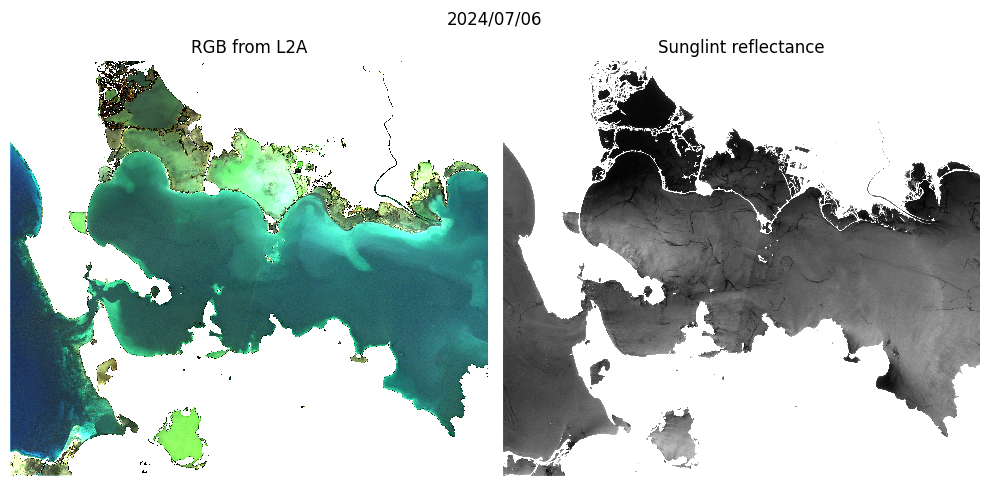

In [5]:


nrows=1
ncols=2
alpha=0.3
l2a_rgb = raster.Rrs.sel(wl= [670,565,490],method='nearest' )
fig,axs = plt.subplots(nrows,ncols,figsize=(ncols*5.,5*nrows),subplot_kw={'projection': proj}) 
fig.subplots_adjust(bottom=0.08, top=0.9, left=0.086, right=0.98,
                    hspace=0.05, wspace=0.07,)
if (ncols == 1) & (nrows == 1):
    axs = np.array([axs])
axs=axs.ravel()
[axi.set_axis_off() for axi in axs]   

ax=axs[0]


bcmap = mpl.colors.ListedColormap([(0,0,0,0),'green','blue'])
# omni_mask.plot.imshow(cmap=bcmap,alpha=alpha,add_colorbar=False,ax=ax)
l2a_rgb.plot.imshow(rgb='wl', robust=True,ax=ax)
raster['BRDFg'].plot.imshow(cmap=plt.cm.gray, robust=True,vmin=0,vmax=0.04,ax=axs[1],add_colorbar=False)
 

ax.set_title("RGB from L2A")
axs[1].set_title("Sunglint reflectance")

#cbar_ax = fig.add_axes([0.3, 0.0, 0.4, 0.02])  # Left, bottom, width, height.
#cbar = fig.colorbar(im, cax=cbar_ax, extend='both', orientation='horizontal')
#cbar.set_label('$SPM\ (mg\cdot L^{-1})$')
plt.suptitle(date)
plt.tight_layout()


In [6]:
OWT = GRSl2bgen.OWT(prod.raster,
                    owt_database='Spyrakos2018')


(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='$Wavelength\\ (nm)$', ylabel='$Standardized\\ R_{rs}\\ (nm^{-1})$'>)

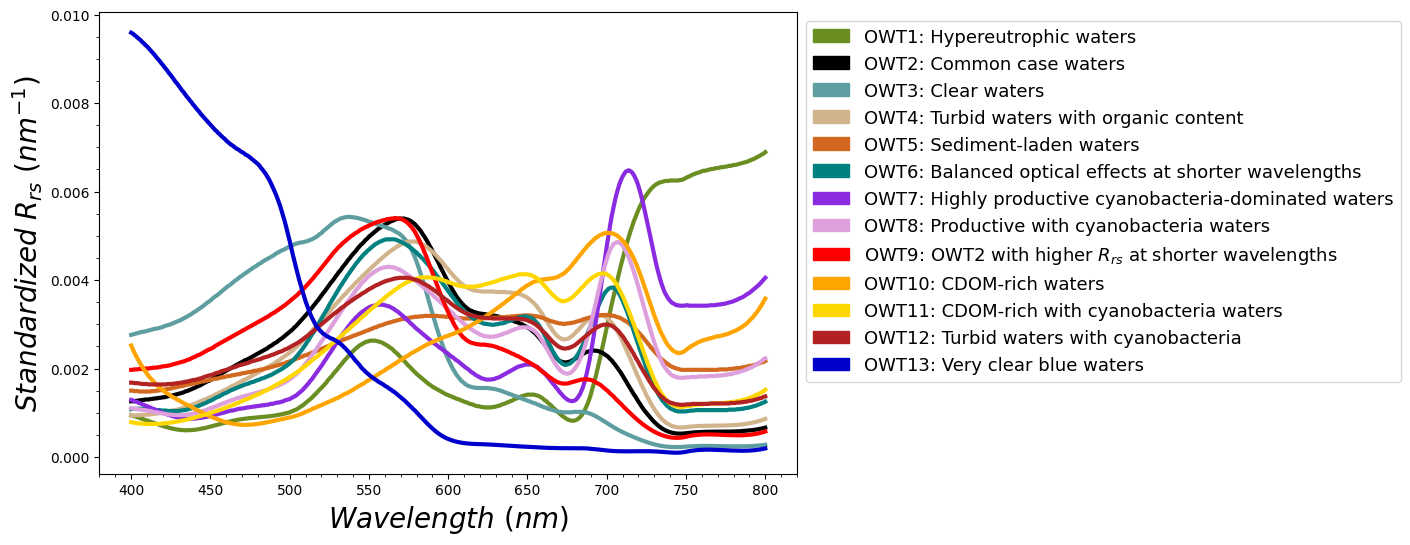

In [7]:
OWT.plot()

In [8]:
xowt_prod = OWT.multi_process()

INFO:root:OWT classification


INFO:root:success


INFO:root:construct xarray owt product


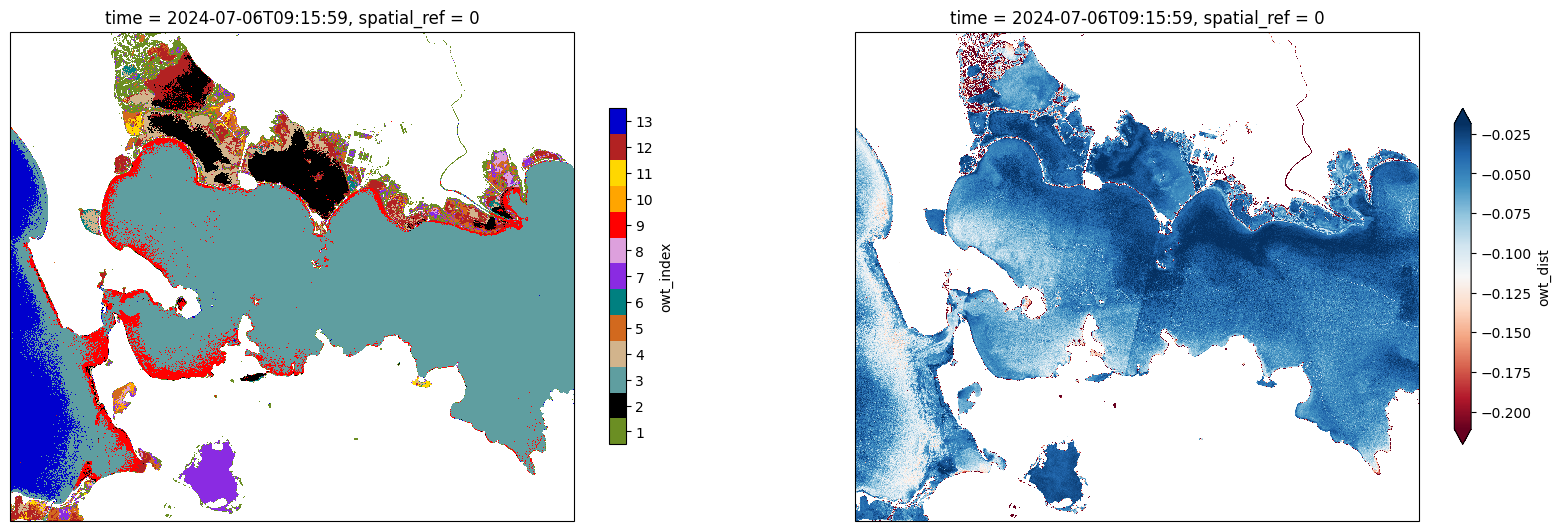

In [9]:
fig = plt.figure(figsize=(20, 15))

ax = plt.subplot(2, 2, 1, projection=proj)
xowt_prod.owt_index.plot.imshow(vmin=0.5,vmax=OWT.Nowt+.5,cmap=OWT.cmap_owt,cbar_kwargs={ 'ticks':range(1,OWT.Nowt+1),'shrink': 0.64},ax=ax)

cmap = plt.get_cmap('RdBu')#,13)
ax = plt.subplot(2, 2, 2, projection=proj)
xowt_prod.owt_dist.plot.imshow(robust=True,cmap=cmap,ax=ax, cbar_kwargs={ 'shrink': 0.64})

(<Figure size 900x600 with 1 Axes>,
 <Axes: xlabel='$Wavelength\\ (nm)$', ylabel='$Standardized\\ R_{rs}\\ (nm^{-1})$'>)

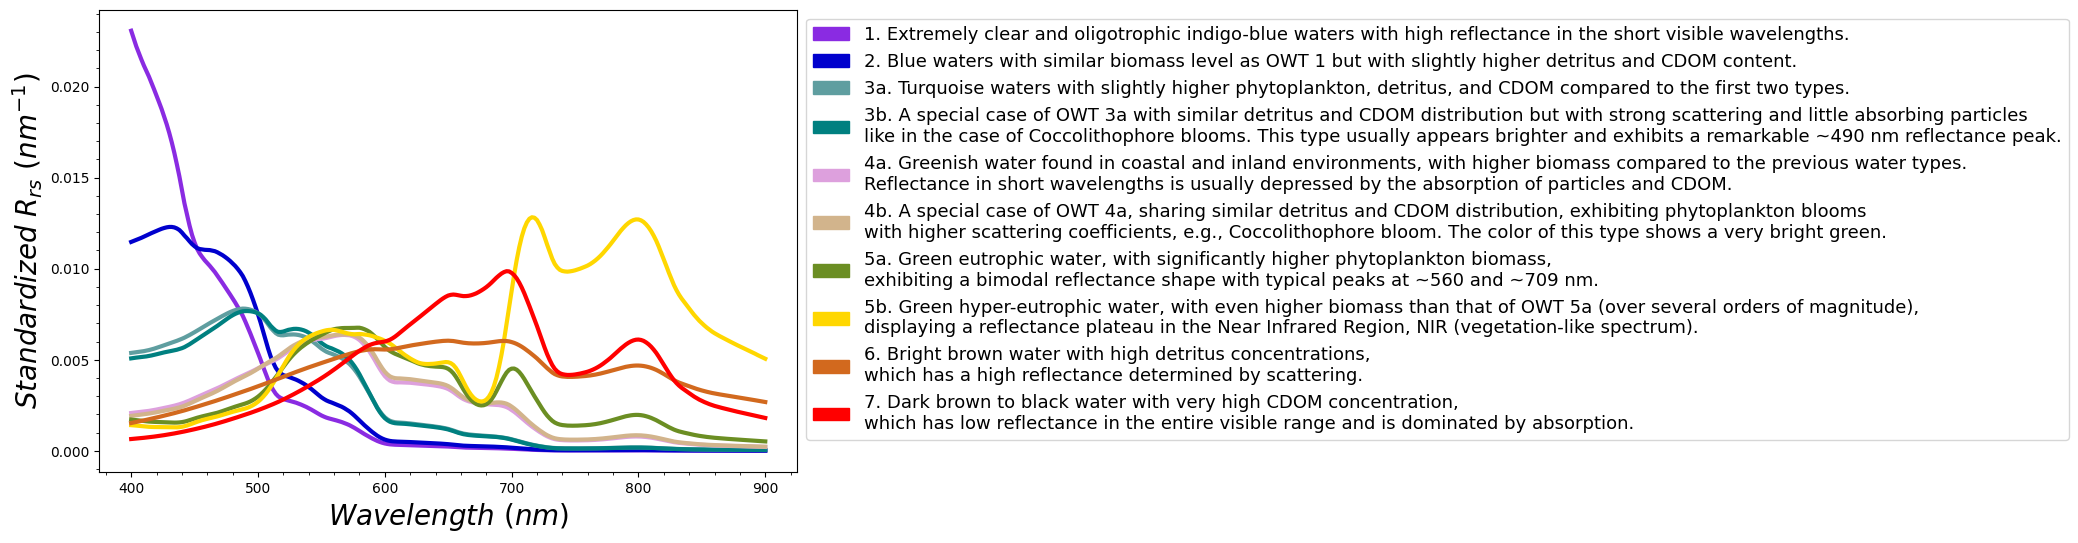

In [10]:
OWT = GRSl2bgen.OWT(prod.raster,
                    owt_database='Bi2024')

OWT.plot()

In [11]:
xowt_prod = OWT.multi_process()

INFO:root:OWT classification


INFO:root:success


INFO:root:construct xarray owt product


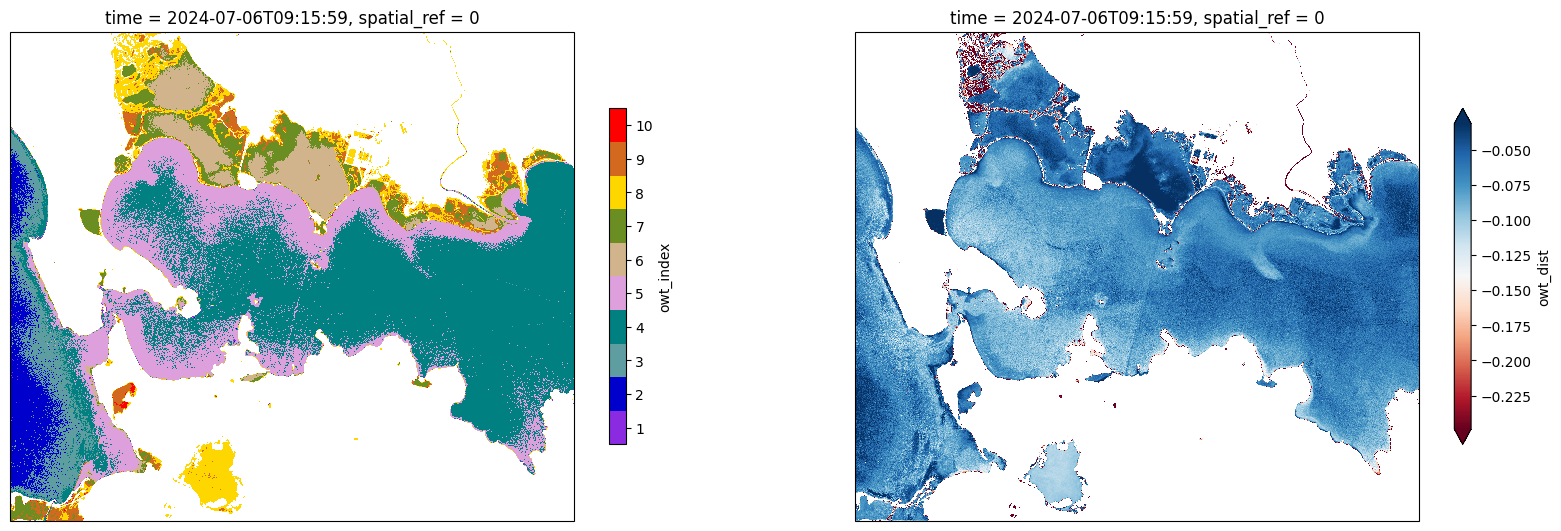

In [12]:
fig = plt.figure(figsize=(20, 15))
OWT.owt['owt']=['1','2','3a','3b','4a','4b','5a','5b','6','7']
ax = plt.subplot(2, 2, 1, projection=proj)
xowt_prod.owt_index.plot.imshow(vmin=0.5,vmax=OWT.Nowt+.5,cmap=OWT.cmap_owt,cbar_kwargs={ 'ticks':range(1,OWT.Nowt+1),'shrink': 0.64},ax=ax)

cmap = plt.get_cmap('RdBu')#,13)
ax = plt.subplot(2, 2, 2, projection=proj)
xowt_prod.owt_dist.plot.imshow(robust=True,cmap=cmap,ax=ax, cbar_kwargs={ 'shrink': 0.64})

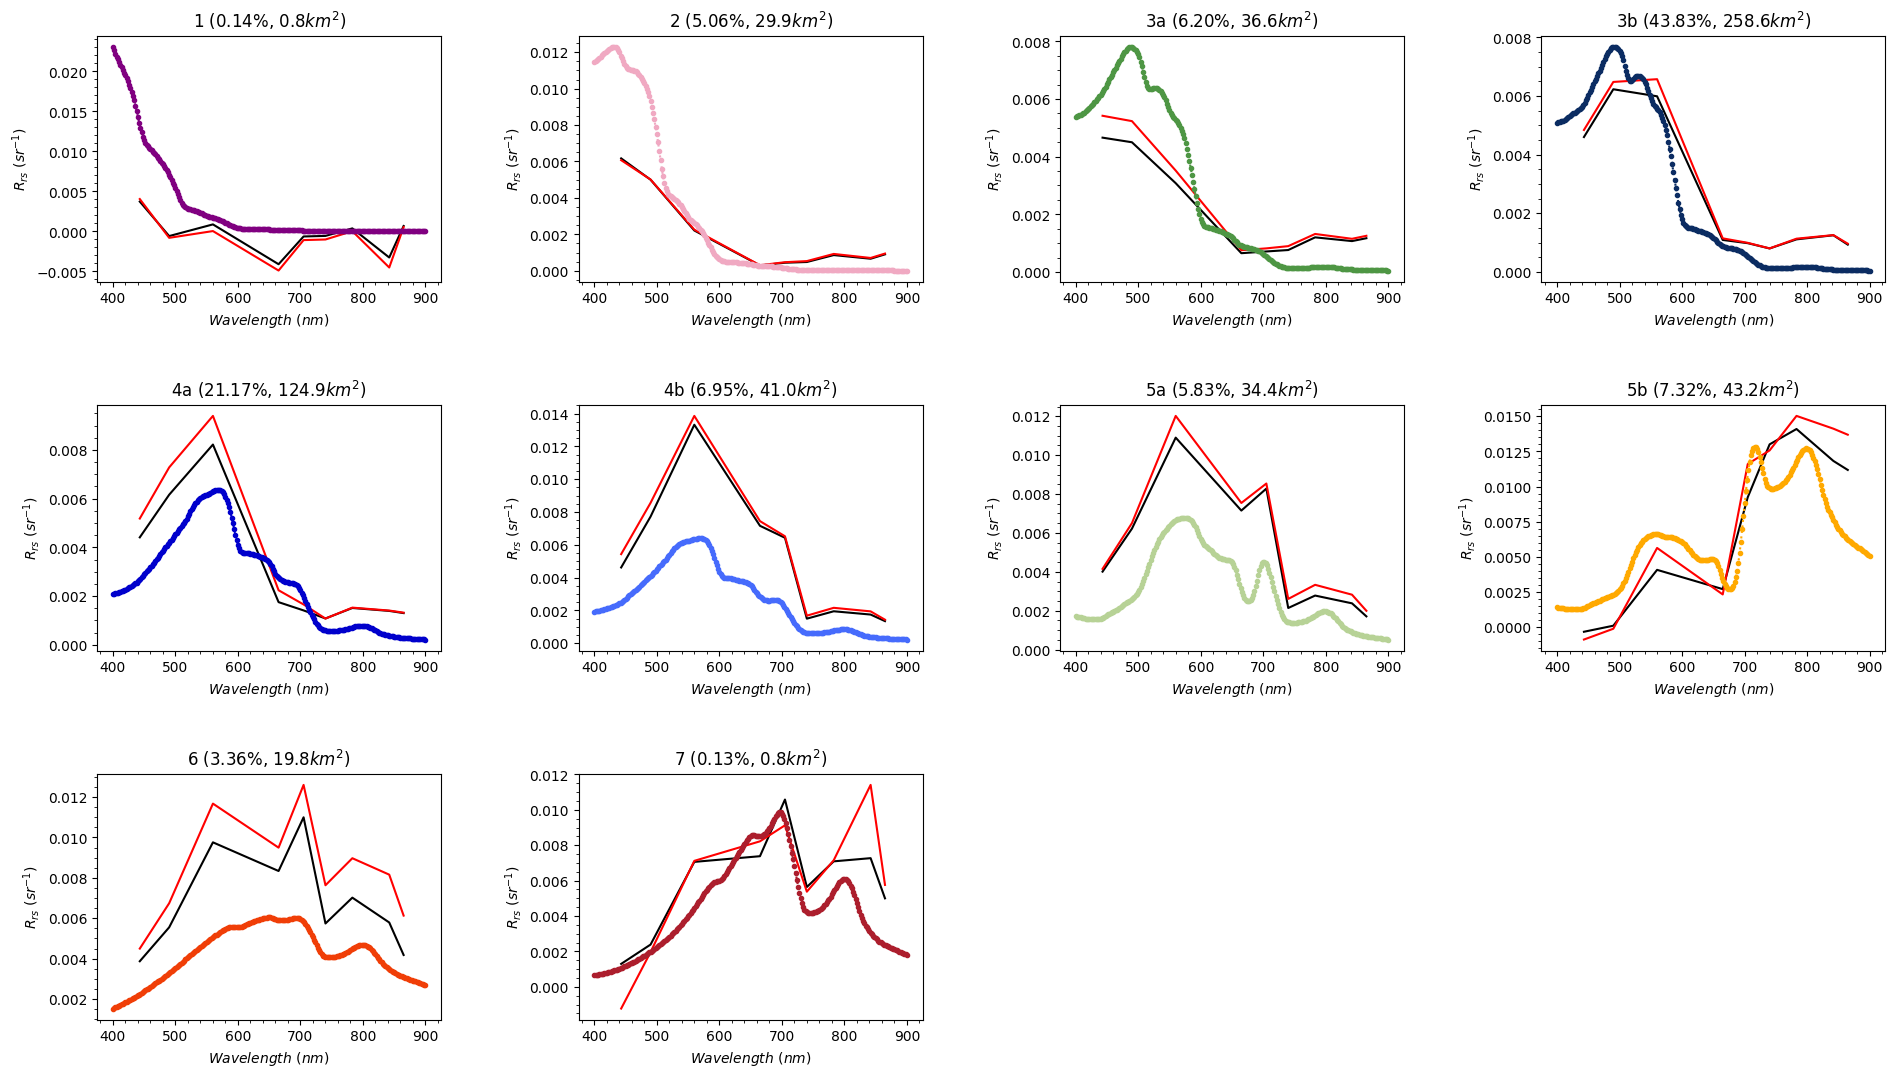

In [13]:
Nowt = OWT.Nowt
owt_roi = np.unique(xowt_prod.owt_index)
owt_roi = owt_roi[~np.isnan(owt_roi)].astype(int)
owt_roi

cmap_ = mpl.colors.LinearSegmentedColormap.from_list("",
                                                    ['purple','pink',
                                                        'forestgreen',#'yellowgreen',
                                                      'navy', "blue", 'lightskyblue',"gold",
                                                     'orangered', "firebrick", 'purple'])
cmap.resampled(Nowt)
color_list = cmap_(np.linspace(0, 1, Nowt, 0))
cmap = cmap_.from_list('',color_list, Nowt)





ncols=4
Nowt_roi = len(owt_roi)
ncols=np.min([ncols,Nowt_roi])
nrows=int(np.ceil(Nowt_roi/ncols))    


norm = mpl.colors.Normalize(vmin=0.5, vmax=Nowt+0.5)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig,axs = plt.subplots(nrows,ncols,figsize=(ncols*5,4*nrows)) 
fig.subplots_adjust(bottom=0.08, top=0.9, left=0.086, right=0.98,
                    hspace=0.5, wspace=0.4)
if (ncols == 1) & (nrows == 1):
    axs = np.array([axs])
axs=axs.ravel()
[axi.set_axis_off() for axi in axs]
Rrs_raster = raster.Rrs.sel(wl=slice(400,1000))
Ntot = Rrs_raster.isel(wl=1).count()
for ii,owt_ in enumerate(owt_roi):
    ax=axs[ii]
    ax.set_axis_on()
    ax.minorticks_on()

    Rrs_roi = Rrs_raster.where(xowt_prod.owt_index==owt_)
    Npix = Rrs_roi.isel(wl=1).count()
    res=20e-3
    area = Npix*pixel_area*1e-6
    Rrs_roi.median(['x','y']).plot(c='k',label='median',ax=ax)
    Rrs_roi.mean(['x','y']).plot(c='r',label='mean',ax=ax)
    #ax.fill_between(wl, stats['isRrs_q25'], stats['isRrs_q75'],alpha=0.3,color='grey')
    #ax.fill_between(wl, stats['isRrs_min'], stats['isRrs_max'],alpha=0.1,color='grey')
    OWT.owt.isel(owt=owt_-1).plot(c=cmap(norm(owt_)),marker='o',ms=3,ls=':',label='OWT',ax=ax)
    ax.set_xlabel(r'$Wavelength\ (nm)$')
    ax.set_ylabel(r'$R_{rs}\ (sr^{-1})$')
    ax.set_title(str(OWT.owt.owt.values[owt_-1])+f' ({(Npix/Ntot*100).values:.2f}%, {area.values:.1f}'+r'$km^2$)')